# Домашнее задание 4: PWM and Markov Models

In [30]:
!pip install biopython

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from Bio import SeqIO, motifs
from Bio.Seq import Seq
import warnings
warnings.filterwarnings('ignore')

BACKGROUND = {'A': 0.295, 'C': 0.205, 'G': 0.205, 'T': 0.295}
NUCLEOTIDES = ['A', 'C', 'G', 'T']
BG_PROBS = np.array([BACKGROUND[n] for n in NUCLEOTIDES])

---
# Часть I: Моделирование мотивов и PWM

## Задание 1. Реализация PWM «с нуля»

In [32]:
sites = [
    "GAGGTAAAC", "TCCGTAAGC", "CAGGTTGGA",
    "ACAGTCAGC", "TAGGTCAGC", "CAGGTCAGC",
    "CAGGTCGAT", "CAGGTCAGC", "CAGGTCAGC",
    "CAGGTTGGC"
]
L = len(sites[0])
N = len(sites)

**PFM** — считаем, сколько раз каждый нуклеотид встречается на каждой позиции.

In [33]:
def compute_pfm(sites):
    L = len(sites[0])
    pfm = np.zeros((4, L), dtype=float)
    nuc_idx = {n: i for i, n in enumerate(NUCLEOTIDES)}
    for seq in sites:
        for pos, nuc in enumerate(seq):
            pfm[nuc_idx[nuc], pos] += 1
    return pfm

pfm = compute_pfm(sites)
print('PFM (строки: A,C,G,T | столбцы: позиции 1..9):')
print(pfm)

PFM (строки: A,C,G,T | столбцы: позиции 1..9):
[[ 1.  8.  1.  0.  0.  2.  7.  2.  1.]
 [ 6.  2.  1.  0.  0.  6.  0.  0.  8.]
 [ 1.  0.  8. 10.  0.  0.  3.  8.  0.]
 [ 2.  0.  0.  0. 10.  2.  0.  0.  1.]]


**PPM** — нормализуем PFM в вероятности, добавляя псевдосчёт α=0.1, чтобы избежать нулевых вероятностей:

$$PPM_{b,i} = \frac{count_{b,i} + \alpha}{N + 4\alpha}$$

In [34]:
def pfm_to_ppm(pfm, alpha=0.1):
    N = pfm.sum(axis=0)
    return (pfm + alpha) / (N + 4 * alpha)

ppm = pfm_to_ppm(pfm)
np.set_printoptions(precision=4)
print('PPM:')
print(ppm)
print('Суммы по столбцам:', ppm.sum(axis=0).round(6))

PPM:
[[0.1058 0.7788 0.1058 0.0096 0.0096 0.2019 0.6827 0.2019 0.1058]
 [0.5865 0.2019 0.1058 0.0096 0.0096 0.5865 0.0096 0.0096 0.7788]
 [0.1058 0.0096 0.7788 0.9712 0.0096 0.0096 0.2981 0.7788 0.0096]
 [0.2019 0.0096 0.0096 0.0096 0.9712 0.2019 0.0096 0.0096 0.1058]]
Суммы по столбцам: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


**PWM** — логарифм отношения вероятности к фону. Положительное значение означает, что нуклеотид встречается чаще случайного, отрицательное — реже:

$$PWM_{b,i} = \log_2\frac{PPM_{b,i}}{background_b}$$

In [35]:
def ppm_to_pwm(ppm, background=BACKGROUND):
    bg = np.array([background[n] for n in NUCLEOTIDES]).reshape(-1, 1)
    return np.log2(ppm / bg)

pwm = ppm_to_pwm(ppm)
print('PWM (log-odds):')
print(pwm)

PWM (log-odds):
[[-1.4798  1.4006 -1.4798 -4.9392 -4.9392 -0.5469  1.2105 -0.5469 -1.4798]
 [ 1.5166 -0.0218 -0.9547 -4.4141 -4.4141  1.5166 -4.4141 -4.4141  1.9257]
 [-0.9547 -4.4141  1.9257  2.2441 -4.4141 -4.4141  0.5401  1.9257 -4.4141]
 [-0.5469 -4.9392 -4.9392 -4.9392  1.719  -0.5469 -4.9392 -4.9392 -1.4798]]


Максимальный скор достигается, если на каждой позиции выбрать нуклеотид с наибольшим весом, минимальный — с наименьшим.

In [36]:
def score_sequence(seq, pwm):
    nuc_idx = {n: i for i, n in enumerate(NUCLEOTIDES)}
    return sum(pwm[nuc_idx[nuc], pos] for pos, nuc in enumerate(seq))

max_seq = ''.join(NUCLEOTIDES[i] for i in pwm.argmax(axis=0))
min_seq = ''.join(NUCLEOTIDES[i] for i in pwm.argmin(axis=0))

print(f'Максимальный скор: {pwm.max(axis=0).sum():.4f}  →  {max_seq}')
print(f'Минимальный скор:  {pwm.min(axis=0).sum():.4f}  →  {min_seq}')

Максимальный скор: 15.3846  →  CAGGTCAGC
Минимальный скор:  -39.9434  →  ATTAAGTTG


## Задание 2. Сканирование хромосомы человека

In [37]:
CHR1_PATH = 'chr1.fa'

import urllib.request, gzip, shutil
urllib.request.urlretrieve(
    'https://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/chr1.fa.gz',
    'chr1.fa.gz'
)
with gzip.open('chr1.fa.gz', 'rb') as f_in, open(CHR1_PATH, 'wb') as f_out:
    shutil.copyfileobj(f_in, f_out)

In [38]:
bio_sites = [Seq(s) for s in sites]
m = motifs.create(bio_sites)
m.background = BACKGROUND

record = next(SeqIO.parse(CHR1_PATH, 'fasta'))
sequence = record.seq[:1_000_000]

print(f'Мотив: {m.consensus}')
print(f'Загружено {len(sequence):,} нуклеотидов')

Мотив: CAGGTCAGC
Загружено 1,000,000 нуклеотидов


Транскрипционные факторы могут связываться на обеих цепях ДНК, поэтому ищем и на прямой, и на обратно-комплементарной.

In [39]:
THRESHOLD = 5.0
pssm = m.pssm
hits = []

for pos, score in pssm.search(sequence, threshold=THRESHOLD):
    hits.append((pos, '+', round(score, 4)))

for pos, score in pssm.reverse_complement().search(sequence, threshold=THRESHOLD):
    hits.append((pos, '-', round(score, 4)))

hits.sort(key=lambda x: x[0])

print(f'Найдено хитов (score > {THRESHOLD}): {len(hits)}')
print('\nПервые 20:')
for h in hits[:20]:
    print(f'  pos={h[0]:>8},  strand={h[1]},  score={h[2]:.4f}')

Найдено хитов (score > 5.0): 3084

Первые 20:
  pos= -989500,  strand=+,  score=12.2002
  pos= -988998,  strand=+,  score=8.4430
  pos= -988679,  strand=+,  score=5.5051
  pos= -988132,  strand=+,  score=7.5650
  pos= -988124,  strand=-,  score=8.6654
  pos= -988109,  strand=+,  score=7.0901
  pos= -987988,  strand=+,  score=6.0901
  pos= -987776,  strand=-,  score=5.0901
  pos= -987324,  strand=+,  score=11.5029
  pos= -986866,  strand=+,  score=9.3928
  pos= -986670,  strand=-,  score=7.0901
  pos= -986540,  strand=-,  score=6.8078
  pos= -986133,  strand=-,  score=6.9800
  pos= -985944,  strand=-,  score=5.4527
  pos= -985759,  strand=+,  score=8.1403
  pos= -985720,  strand=-,  score=15.7252
  pos= -984852,  strand=-,  score=8.6152
  pos= -983992,  strand=+,  score=5.5051
  pos= -983885,  strand=+,  score=6.0901
  pos= -983149,  strand=+,  score=6.2827


## Задание 3. Эмпирическое распределение и p-value

In [40]:
np.random.seed(42)
N_RANDOM = 100_000

rand_seqs = np.random.choice(4, size=(N_RANDOM, L), p=BG_PROBS)
scores = np.sum(pwm[rand_seqs, np.arange(L)], axis=1)

print(f'Средний скор: {scores.mean():.4f}')
print(f'Макс: {scores.max():.4f},  Мин: {scores.min():.4f}')

Средний скор: -16.5902
Макс: 12.6506,  Мин: -39.9434


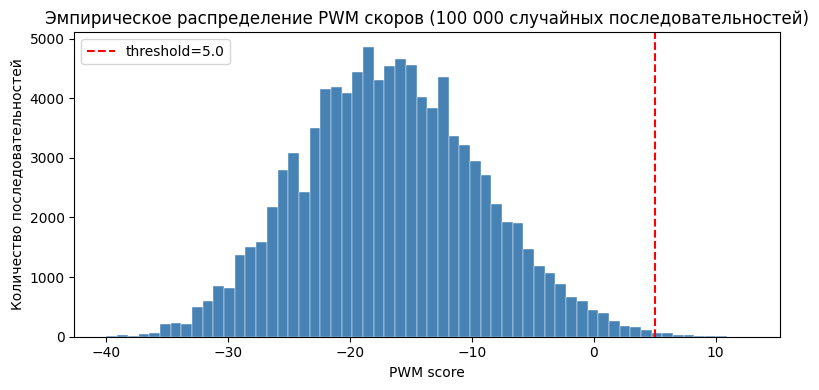

In [41]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(scores, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
ax.axvline(x=5.0, color='red', linestyle='--', label='threshold=5.0')
ax.set_xlabel('PWM score')
ax.set_ylabel('Количество последовательностей')
ax.set_title('Эмпирическое распределение PWM скоров (100 000 случайных последовательностей)')
ax.legend()
plt.tight_layout()
plt.show()

Порог для p-value ≈ 10⁻⁴ — это 99.99-й процентиль распределения фоновых скоров.

In [42]:
def get_pvalue(score, background_scores=scores):
    return (background_scores >= score).mean()

threshold_1e4 = np.sort(scores)[int(N_RANDOM * (1 - 1e-4))]

print(f'Порог для p-value ≈ 1e-4: {threshold_1e4:.4f}')
print(f'Проверка: p-value = {get_pvalue(threshold_1e4):.2e}')

for s in [3.0, 4.0, 5.0, threshold_1e4]:
    print(f'  p-value({s:.3f}) = {get_pvalue(s):.2e}')

Порог для p-value ≈ 1e-4: 10.5566
Проверка: p-value = 1.00e-04
  p-value(3.000) = 5.07e-03
  p-value(4.000) = 3.32e-03
  p-value(5.000) = 2.18e-03
  p-value(10.557) = 1.00e-04


## Задание 4. Энтропия и информационное содержание

$$H(i) = -\sum_b p_{b,i}\log_2 p_{b,i}, \qquad IC(i) = 2 - H(i)$$

IC = 0 означает равновероятное распределение (позиция не информативна), IC = 2 — единственный нуклеотид (максимальная консервативность).

In [43]:
p = np.where(ppm > 0, ppm, 1e-12)
H = -np.sum(p * np.log2(p), axis=0)
IC = 2 - H

print('Позиция | H(i)  | IC(i)')
print('-' * 30)
for i in range(L):
    print(f'   {i+1:2d}   | {H[i]:.4f} | {IC[i]:.4f}')

Позиция | H(i)  | IC(i)
------------------------------
    1   | 1.6031 | 0.3969
    2   | 0.8758 | 1.1242
    3   | 1.0309 | 0.9691
    4   | 0.2343 | 1.7657
    5   | 0.2343 | 1.7657
    6   | 1.4480 | 0.5520
    7   | 1.0253 | 0.9747
    8   | 0.8758 | 1.1242
    9   | 1.0309 | 0.9691


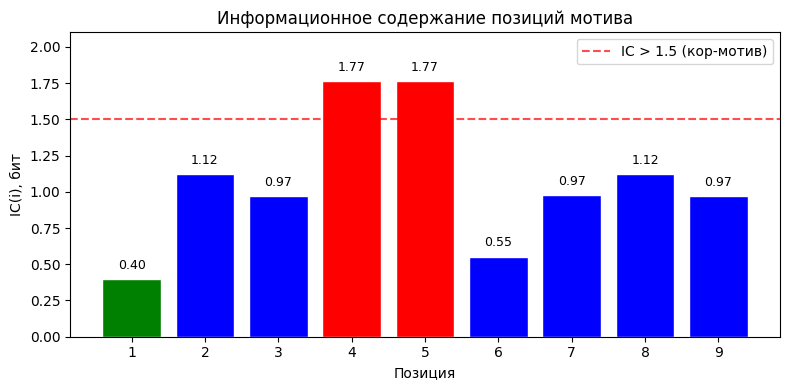

In [44]:
colors = ['red' if ic > 1.5 else 'blue' if ic > 0.5 else 'green' for ic in IC]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(1, L+1), IC, color=colors, edgecolor='white')
ax.axhline(y=1.5, color='red', linestyle='--', alpha=0.7, label='IC > 1.5 (кор-мотив)')
ax.set_xlabel('Позиция')
ax.set_ylabel('IC(i), бит')
ax.set_title('Информационное содержание позиций мотива')
ax.set_xticks(range(1, L+1))
ax.set_ylim(0, 2.1)
ax.legend()
for bar, ic_val in zip(bars, IC):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{ic_val:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [45]:
core = [i+1 for i, ic in enumerate(IC) if ic > 1.5]
variable = [i+1 for i, ic in enumerate(IC) if ic <= 0.5]

print(f'Кор-мотив (IC > 1.5): позиции {core}')
print(f'Вариабельные (IC ≤ 0.5): позиции {variable}')
print()
print('Выравнивание:')
print('Pos:  1 2 3 4 5 6 7 8 9')
for s in sites:
    print('      ' + ' '.join(s))

Кор-мотив (IC > 1.5): позиции [4, 5]
Вариабельные (IC ≤ 0.5): позиции [1]

Выравнивание:
Pos:  1 2 3 4 5 6 7 8 9
      G A G G T A A A C
      T C C G T A A G C
      C A G G T T G G A
      A C A G T C A G C
      T A G G T C A G C
      C A G G T C A G C
      C A G G T C G A T
      C A G G T C A G C
      C A G G T C A G C
      C A G G T T G G C


Позиции с высоким IC (красные на графике) соответствуют консервативным нуклеотидам — их видно при визуальном осмотре выравнивания (CAGGT присутствует в большинстве сайтов). Вариабельные позиции — на краях мотива.

---
# Часть II: Марковские цепи

## Задание 5. Матрица переходов ДНК 1-го порядка

In [46]:
SEQ_FASTA = 'sequence.fasta'

chr1_rec = next(SeqIO.parse(CHR1_PATH, 'fasta'))
clean = ''.join(c for c in str(chr1_rec.seq[100_000:110_000]).upper() if c in 'ACGT')[:10_000]
with open(SEQ_FASTA, 'w') as f:
    f.write('>sequence\n' + clean + '\n')

In [47]:
record = SeqIO.read(SEQ_FASTA, 'fasta')
seq = ''.join(c for c in str(record.seq).upper() if c in 'ACGT')
print(f'Длина последовательности: {len(seq)}')

Длина последовательности: 10000


In [48]:
nuc_idx = {n: i for i, n in enumerate(NUCLEOTIDES)}

dinuc_counts = np.zeros((4, 4))
for i in range(len(seq) - 1):
    if seq[i] in nuc_idx and seq[i+1] in nuc_idx:
        dinuc_counts[nuc_idx[seq[i]], nuc_idx[seq[i+1]]] += 1

P = dinuc_counts / dinuc_counts.sum(axis=1, keepdims=True)

print('Матрица переходов P[i to j] (строки/столбцы: A,C,G,T):')
print('    ', '  '.join(f'{n:6s}' for n in NUCLEOTIDES))
for i, n in enumerate(NUCLEOTIDES):
    print(f'{n}:  ' + '  '.join(f'{P[i,j]:.4f}' for j in range(4)))
print('\nСуммы строк:', P.sum(axis=1).round(6))

Матрица переходов P[i to j] (строки/столбцы: A,C,G,T):
     A       C       G       T     
A:  0.3406  0.1805  0.2376  0.2413
C:  0.3968  0.2227  0.0260  0.3546
G:  0.3234  0.2072  0.2420  0.2274
T:  0.2449  0.2154  0.2504  0.2893

Суммы строк: [1. 1. 1. 1.]


Стационарное распределение π — это левый собственный вектор матрицы P для собственного значения λ=1. Он описывает предельные частоты нуклеотидов при бесконечно длинной прогулке по цепи.

In [49]:
eigenvalues, eigenvectors = np.linalg.eig(P.T)
idx = np.argmin(np.abs(eigenvalues - 1.0))
pi = np.real(eigenvectors[:, idx])
pi /= pi.sum()

obs_freq = np.array([seq.count(n) for n in NUCLEOTIDES], dtype=float)
obs_freq /= obs_freq.sum()

print(f'{"":4s}  {"pi (стац.)":12s}  {"наблюдаемые":12s}')
for i, n in enumerate(NUCLEOTIDES):
    print(f'{n}:    {pi[i]:.6f}      {obs_freq[i]:.6f}')

      pi (стац.)    наблюдаемые 
A:    0.322337      0.322400
C:    0.204025      0.204000
G:    0.198798      0.198800
T:    0.274840      0.274800
